Mini-project: Advanced Statistical Analysis of Apple Inc. Stock Data


👩‍🏫 👩🏿‍🏫 What You’ll learn
Master statistical analysis of financial data using NumPy and SciPy.
Learn effective data visualization techniques with Matplotlib for financial trends.
Apply hypothesis testing to financial datasets for meaningful insights.
Understand and utilize advanced statistical techniques in NumPy and SciPy.


Project Description
Using the AAPL (Apple Inc.) stock dataset, conduct the following analyses:



Initial Data Exploration
Load the dataset using Pandas. Check for null values and understand data types.
Examine the time series properties of the data (e.g., frequency, trends).


Data Visualization
Utilize Matplotlib to plot closing prices and traded volume over time.
Create a candlestick chart to depict high and low prices.


Statistical Analysis
Compute summary statistics (mean, median, standard deviation) for key columns.
Analyze closing prices with a moving average.


Hypothesis Testing
Execute a t-test to compare average closing prices across different years.
Examine daily returns’ distribution and test for normality using SciPy.


Load the dataset using Pandas. Check for null values and understand data types.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Apple Stock Prices (1981 to 2023).csv')
print(df['Date'].head)
print("\n2. Null Values Per Column:")
print(df.isnull().sum())
df.info()

# Convert with exact format (FASTEST) - The dates were a string and we want to be able to use them with pandas.
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Set as index for time series work
df = df.set_index('Date')
df = df.sort_index()

print(df.info())
print(df.head())
print(f"\nFirst 5 rows:")
print(df.head())

<bound method NDFrame.head of 0        02/01/1981
1        05/01/1981
2        06/01/1981
3        07/01/1981
4        08/01/1981
            ...    
10603    23/01/2023
10604    24/01/2023
10605    25/01/2023
10606    26/01/2023
10607    27/01/2023
Name: Date, Length: 10608, dtype: str>

2. Null Values Per Column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  str    
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 580.3 KB
<class 'pandas.DataFrame'>
DatetimeIndex: 10608 

Examine the time series properties of the data (e.g., frequency, trends).

In [2]:
# 1. FREQUENCY
print("\n1. FREQUENCY ANALYSIS")
print("-" * 80)
date_diffs = df.index.to_series().diff().dt.days
print(f"Mean days between records: {date_diffs.mean():.2f}")
print(f"Mode: {date_diffs.mode().values[0]:.0f} days")
print(f"Range: {date_diffs.min():.0f} to {date_diffs.max():.0f} days")

# 2. TIME SPAN
print("\n2. TIME SPAN ANALYSIS")
print("-" * 80)
start = df.index.min()
end = df.index.max()
days = (end - start).days
years = days / 365.25
print(f"Start: {start.date()}")
print(f"End: {end.date()}")
print(f"Duration: {days:,} days ({years:.1f} years)")
print(f"Total records: {len(df):,}")

# 3. TREND
print("\n3. TREND ANALYSIS")
print("-" * 80)
first = df['Adj Close'].iloc[0]
last = df['Adj Close'].iloc[-1]
change = last - first
change_pct = (change / first) * 100
ann_return = ((last / first) ** (1/years) - 1) * 100
print(f"Starting price: ${first:.4f}")
print(f"Ending price: ${last:.2f}")
print(f"Total return: {change_pct:,.2f}%")
print(f"Annualized return: {ann_return:.2f}%")
print(f"Trend: {' UPTREND' if change > 0 else ' DOWNTREND'}")

# 4. VOLATILITY
print("\n4. VOLATILITY ANALYSIS")
print("-" * 80)
std = df['Adj Close'].std()
mean = df['Adj Close'].mean()
cv = (std / mean) * 100
print(f"Price std dev: ${std:.2f}")
print(f"Mean price: ${mean:.2f}")
print(f"Coefficient of variation: {cv:.2f}%")
df['Daily_Return'] = df['Adj Close'].pct_change() * 100
daily_vol = df['Daily_Return'].std()
print(f"Daily return volatility: {daily_vol:.4f}%")

# 5. UP vs DOWN
print("\n5. UP vs DOWN DAYS")
print("-" * 80)
df['Daily_Change'] = df['Close'] - df['Open']
up = (df['Daily_Change'] > 0).sum()
down = (df['Daily_Change'] < 0).sum()
neutral = (df['Daily_Change'] == 0).sum()
print(f"Up days: {up:,} ({up/len(df)*100:.1f}%)")
print(f"Down days: {down:,} ({down/len(df)*100:.1f}%)")
print(f"Neutral: {neutral:,} ({neutral/len(df)*100:.1f}%)")

print("\n" + "="*80)
print("EXAMINATION COMPLETE")
print("="*80)


1. FREQUENCY ANALYSIS
--------------------------------------------------------------------------------
Mean days between records: 1.45
Mode: 1 days
Range: 1 to 7 days

2. TIME SPAN ANALYSIS
--------------------------------------------------------------------------------
Start: 1981-01-02
End: 2023-01-27
Duration: 15,365 days (42.1 years)
Total records: 10,608

3. TREND ANALYSIS
--------------------------------------------------------------------------------
Starting price: $0.1198
Ending price: $145.93
Total return: 121,661.54%
Annualized return: 18.40%
Trend:  UPTREND

4. VOLATILITY ANALYSIS
--------------------------------------------------------------------------------
Price std dev: $35.15
Mean price: $16.03
Coefficient of variation: 219.34%
Daily return volatility: 2.8233%

5. UP vs DOWN DAYS
--------------------------------------------------------------------------------
Up days: 4,842 (45.6%)
Down days: 5,048 (47.6%)
Neutral: 718 (6.8%)

EXAMINATION COMPLETE


Utilize Matplotlib to plot closing prices and traded volume over time.

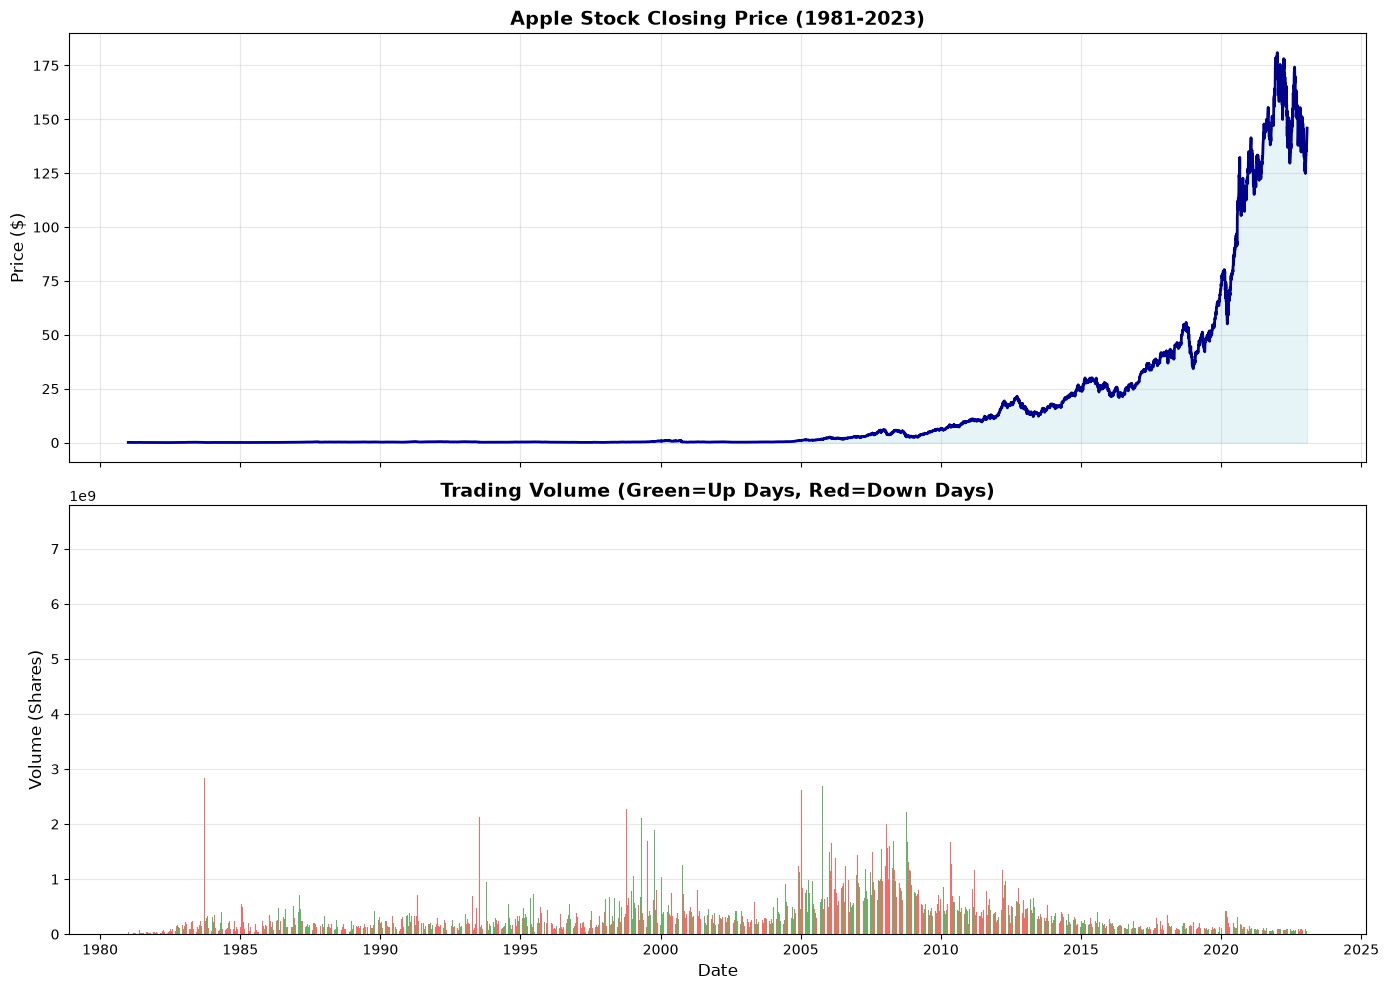

In [3]:
# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot 1: Closing Price
ax1.plot(df.index, df['Adj Close'], linewidth=2, color='darkblue')
ax1.fill_between(df.index, df['Adj Close'], alpha=0.3, color='lightblue')
ax1.set_title('Apple Stock Closing Price (1981-2023)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Trading Volume
colors = ['green' if df['Close'].iloc[i] > df['Open'].iloc[i] else 'red' 
          for i in range(len(df))]
ax2.bar(df.index, df['Volume'], color=colors, alpha=0.6, width=1)
ax2.set_title('Trading Volume (Green=Up Days, Red=Down Days)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Volume (Shares)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Create a candlestick chart to depict high and low prices.

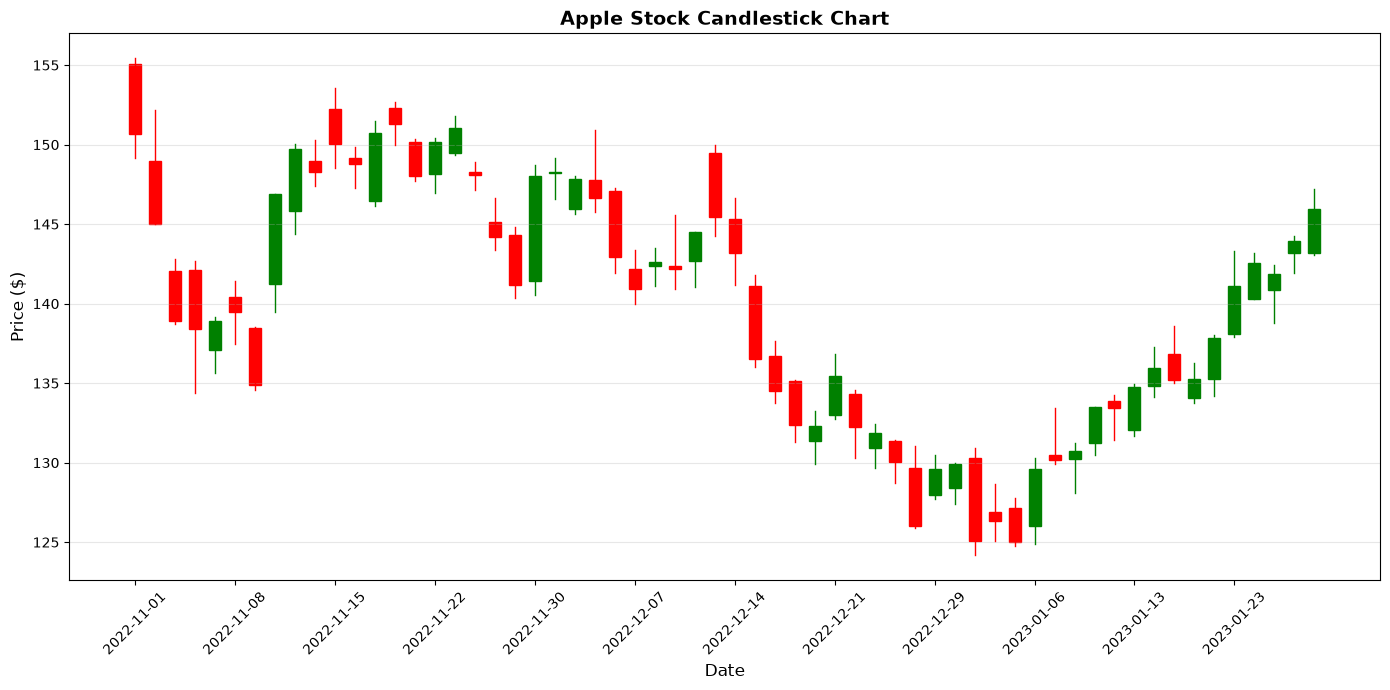

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Your df is already processed with dates!
# Just use it directly - no need to reload

# Get last 60 days
df_recent = df.tail(60)

# Create plot
fig, ax = plt.subplots(figsize=(14, 7))

# Draw candlesticks
for idx, (date, row) in enumerate(df_recent.iterrows()):
    color = 'green' if row['Close'] > row['Open'] else 'red'
    
    # Wick
    ax.plot([idx, idx], [row['Low'], row['High']], color=color, linewidth=1)
    
    # Body
    body_height = abs(row['Close'] - row['Open'])
    body_bottom = min(row['Open'], row['Close'])
    rect = Rectangle((idx - 0.3, body_bottom), 0.6, body_height, 
                     facecolor=color, edgecolor=color)
    ax.add_patch(rect)

# Labels
ax.set_xticks(range(0, len(df_recent), 5))
ax.set_xticklabels([df_recent.index[i].strftime('%Y-%m-%d') 
                     for i in range(0, len(df_recent), 5)], rotation=45)

ax.set_title('Apple Stock Candlestick Chart', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Compute summary statistics (mean, median, standard deviation) for key columns.
Analyze closing prices with a moving average.

In [9]:
print("="*80)
print("SUMMARY STATISTICS - APPLE STOCK DATA")
print("="*80)

# Define key columns
key_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

# Method 1: Quick summary with describe()
print("\n" + "="*80)
print("QUICK SUMMARY")
print("="*80)
print(df[key_columns].describe())

# Method 2: Mean, Median, Standard Deviation (Custom)
print("\n" + "="*80)
print("METHOD 2: MEAN, MEDIAN, STANDARD DEVIATION")
print("="*80)

stats = pd.DataFrame({
    'Mean': df[key_columns].mean(),
    'Median': df[key_columns].median(),
    'Standard Deviation': df[key_columns].std()
})

print("\n")
print(stats)

# Method 3: Detailed view for each column
print("\n" + "="*80)
print("METHOD 3: DETAILED VIEW - BY COLUMN")
print("="*80)

for col in key_columns:
    mean_val = df[col].mean()
    median_val = df[col].median()
    std_val = df[col].std()
    
    print(f"\n{col}:")
    print(f"  Mean:                {mean_val:.4f}")
    print(f"  Median:              {median_val:.4f}")
    print(f"  Standard Deviation:  {std_val:.4f}")

SUMMARY STATISTICS - APPLE STOCK DATA

QUICK SUMMARY
               Open          High           Low         Close     Adj Close  \
count  10608.000000  10608.000000  10608.000000  10608.000000  10608.000000   
mean      16.689173     16.879955     16.500822     16.697362     16.027345   
std       35.450519     35.882848     35.031289     35.473912     35.154878   
min        0.049665      0.049665      0.049107      0.049107      0.038213   
25%        0.287946      0.296875      0.282355      0.288923      0.238909   
50%        0.488839      0.495536      0.480446      0.487701      0.404851   
75%       16.320893     16.418483     16.151249     16.269554     14.073167   
max      182.630005    182.940002    179.119995    182.009995    180.959747   

             Volume  
count  1.060800e+04  
mean   3.275098e+08  
std    3.378203e+08  
min    0.000000e+00  
25%    1.213044e+08  
50%    2.145976e+08  
75%    4.066804e+08  
max    7.421641e+09  

METHOD 2: MEAN, MEDIAN, STANDARD DEV

CLOSING PRICES WITH MOVING AVERAGES

First 10 rows with Moving Averages:
            Adj Close  MA_50  MA_200
Date                                
1981-01-02   0.119849    NaN     NaN
1981-01-05   0.117244    NaN     NaN
1981-01-06   0.112032    NaN     NaN
1981-01-07   0.107256    NaN     NaN
1981-01-08   0.105085    NaN     NaN
1981-01-09   0.110730    NaN     NaN
1981-01-12   0.109861    NaN     NaN
1981-01-13   0.105953    NaN     NaN
1981-01-14   0.106388    NaN     NaN
1981-01-15   0.108559    NaN     NaN

Last 10 rows with Moving Averages:
             Adj Close       MA_50      MA_200
Date                                          
2023-01-13  134.759995  139.512195  149.475229
2023-01-17  135.940002  139.335199  149.270082
2023-01-18  135.210007  139.266399  149.077014
2023-01-19  135.270004  139.204199  148.885739
2023-01-20  137.869995  139.183199  148.686907
2023-01-23  141.110001  139.215399  148.521099
2023-01-24  142.529999  139.368599  148.378469
2023-01-25  141.860001  

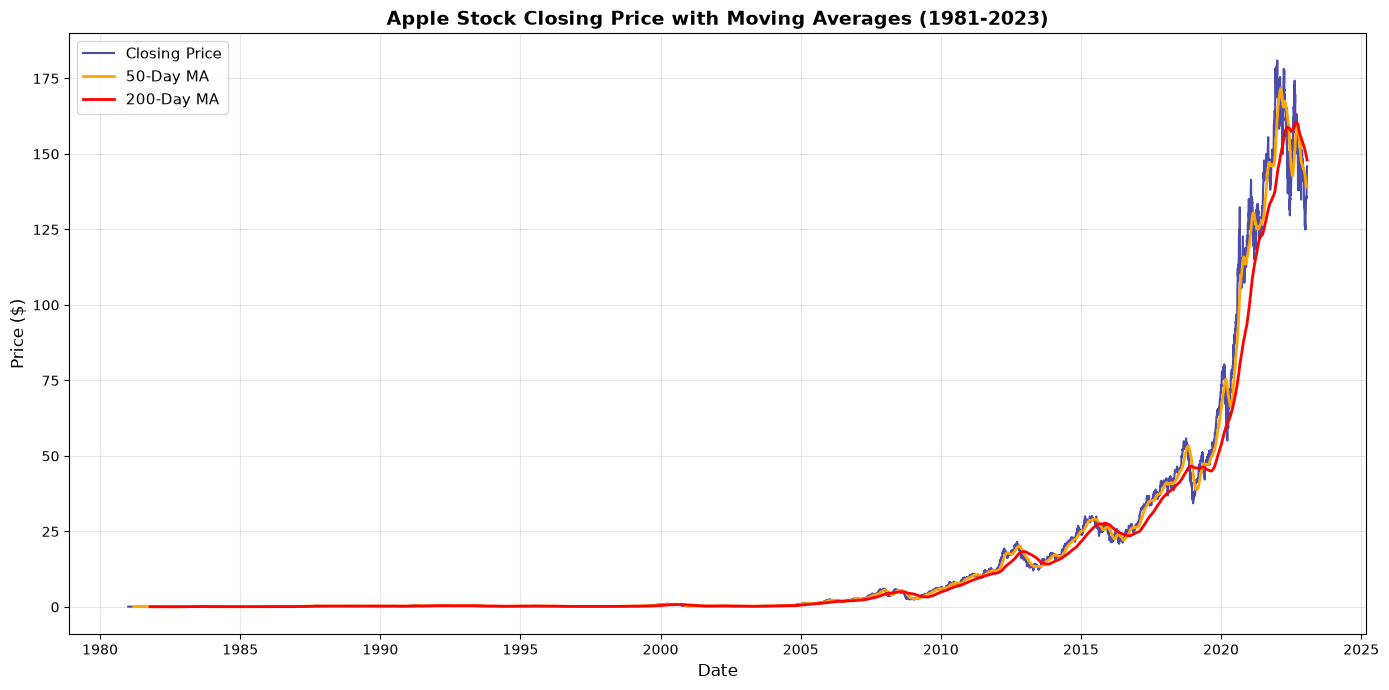

In [10]:
print("CLOSING PRICES WITH MOVING AVERAGES")

# Calculate moving averages
df['MA_50'] = df['Adj Close'].rolling(window=50).mean()   # 50-day MA
df['MA_200'] = df['Adj Close'].rolling(window=200).mean()  # 200-day MA

# Display first few rows with MA
print("\nFirst 10 rows with Moving Averages:")
print(df[['Adj Close', 'MA_50', 'MA_200']].head(10))

print("\nLast 10 rows with Moving Averages:")
print(df[['Adj Close', 'MA_50', 'MA_200']].tail(10))

# Calculate statistics
print("\n" + "="*80)
print("MOVING AVERAGE STATISTICS")
print("="*80)

print("\n50-Day Moving Average:")
print(f"  Mean:   ${df['MA_50'].mean():.2f}")
print(f"  Min:    ${df['MA_50'].min():.2f}")
print(f"  Max:    ${df['MA_50'].max():.2f}")

print("\n200-Day Moving Average:")
print(f"  Mean:   ${df['MA_200'].mean():.2f}")
print(f"  Min:    ${df['MA_200'].min():.2f}")
print(f"  Max:    ${df['MA_200'].max():.2f}")

# Plot
print("\n" + "="*80)
print("PLOTTING CLOSING PRICES WITH MOVING AVERAGES")
print("="*80)

plt.figure(figsize=(14, 7))

# Plot closing price
plt.plot(df.index, df['Adj Close'], linewidth=1.5, label='Closing Price', color='darkblue', alpha=0.7)

# Plot moving averages
plt.plot(df.index, df['MA_50'], linewidth=2, label='50-Day MA', color='orange')
plt.plot(df.index, df['MA_200'], linewidth=2, label='200-Day MA', color='red')

# Formatting
plt.title('Apple Stock Closing Price with Moving Averages (1981-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [11]:
# Analyze last 200 days
df_recent = df.tail(200)

print("\n" + "="*80)
print("RECENT ANALYSIS (Last 200 Days)")
print("="*80)

latest_price = df_recent['Adj Close'].iloc[-1]
latest_ma50 = df_recent['MA_50'].iloc[-1]
latest_ma200 = df_recent['MA_200'].iloc[-1]

print(f"\nCurrent Price:        ${latest_price:.2f}")
print(f"50-Day MA:            ${latest_ma50:.2f}")
print(f"200-Day MA:           ${latest_ma200:.2f}")

print(f"\nPrice vs 50-MA:       {((latest_price/latest_ma50 - 1) * 100):+.2f}%")
print(f"Price vs 200-MA:      {((latest_price/latest_ma200 - 1) * 100):+.2f}%")

if latest_price > latest_ma50 > latest_ma200:
    print("\n✓ STRONG UPTREND (Price > 50-MA > 200-MA)")
elif latest_price > latest_ma50:
    print("\n✓ UPTREND (Price above 50-MA)")
else:
    print("\n✗ DOWNTREND (Price below moving averages)")


RECENT ANALYSIS (Last 200 Days)

Current Price:        $145.93
50-Day MA:            $139.11
200-Day MA:           $148.01

Price vs 50-MA:       +4.91%
Price vs 200-MA:      -1.40%

✓ UPTREND (Price above 50-MA)


Execute a t-test to compare average closing prices across different years.
Examine daily returns’ distribution and test for normality using SciPy.


In [12]:
import pandas as pd
import numpy as np
from scipy import stats

# Your df is already loaded and processed

print("="*80)
print("T-TEST: COMPARING AVERAGE CLOSING PRICES ACROSS YEARS")
print("="*80)

# Extract year from index
df['Year'] = df.index.year

# Get data for specific years
year_2020 = df[df['Year'] == 2020]['Adj Close']
year_2021 = df[df['Year'] == 2021]['Adj Close']
year_2022 = df[df['Year'] == 2022]['Adj Close']
year_2023 = df[df['Year'] == 2023]['Adj Close']

# Display statistics for each year
print("\nAverage Closing Prices by Year:")
print(f"  2020: ${year_2020.mean():.2f}")
print(f"  2021: ${year_2021.mean():.2f}")
print(f"  2022: ${year_2022.mean():.2f}")
print(f"  2023: ${year_2023.mean():.2f}")

# ============================================
# T-TEST 1: 2021 vs 2022
# ============================================
print("\n" + "="*80)
print("T-TEST 1: 2021 vs 2022")
print("="*80)

t_stat_1, p_value_1 = stats.ttest_ind(year_2021, year_2022)

print(f"\n2021 Mean: ${year_2021.mean():.2f}")
print(f"2022 Mean: ${year_2022.mean():.2f}")
print(f"Difference: ${year_2021.mean() - year_2022.mean():.2f}")

print(f"\nT-Statistic: {t_stat_1:.4f}")
print(f"P-Value: {p_value_1:.6f}")

if p_value_1 < 0.05:
    print(f"Result: ✓ SIGNIFICANT DIFFERENCE (p < 0.05)")
    print(f"Interpretation: Prices in 2021 and 2022 are significantly different")
else:
    print(f"Result: ✗ NO SIGNIFICANT DIFFERENCE (p >= 0.05)")
    print(f"Interpretation: Prices in 2021 and 2022 are NOT significantly different")

# ============================================
# T-TEST 2: 2022 vs 2023
# ============================================
print("\n" + "="*80)
print("T-TEST 2: 2022 vs 2023")
print("="*80)

t_stat_2, p_value_2 = stats.ttest_ind(year_2022, year_2023)

print(f"\n2022 Mean: ${year_2022.mean():.2f}")
print(f"2023 Mean: ${year_2023.mean():.2f}")
print(f"Difference: ${year_2022.mean() - year_2023.mean():.2f}")

print(f"\nT-Statistic: {t_stat_2:.4f}")
print(f"P-Value: {p_value_2:.6f}")

if p_value_2 < 0.05:
    print(f"Result: ✓ SIGNIFICANT DIFFERENCE (p < 0.05)")
else:
    print(f"Result: ✗ NO SIGNIFICANT DIFFERENCE (p >= 0.05)")

# ============================================
# T-TEST 3: 2020 vs 2021
# ============================================
print("\n" + "="*80)
print("T-TEST 3: 2020 vs 2021")
print("="*80)

t_stat_3, p_value_3 = stats.ttest_ind(year_2020, year_2021)

print(f"\n2020 Mean: ${year_2020.mean():.2f}")
print(f"2021 Mean: ${year_2021.mean():.2f}")
print(f"Difference: ${year_2020.mean() - year_2021.mean():.2f}")

print(f"\nT-Statistic: {t_stat_3:.4f}")
print(f"P-Value: {p_value_3:.6f}")

if p_value_3 < 0.05:
    print(f"Result: ✓ SIGNIFICANT DIFFERENCE (p < 0.05)")
else:
    print(f"Result: ✗ NO SIGNIFICANT DIFFERENCE (p >= 0.05)")

T-TEST: COMPARING AVERAGE CLOSING PRICES ACROSS YEARS

Average Closing Prices by Year:
  2020: $93.92
  2021: $139.80
  2022: $154.38
  2023: $134.90

T-TEST 1: 2021 vs 2022

2021 Mean: $139.80
2022 Mean: $154.38
Difference: $-14.58

T-Statistic: -11.8181
P-Value: 0.000000
Result: ✓ SIGNIFICANT DIFFERENCE (p < 0.05)
Interpretation: Prices in 2021 and 2022 are significantly different

T-TEST 2: 2022 vs 2023

2022 Mean: $154.38
2023 Mean: $134.90
Difference: $19.48

T-Statistic: 6.3680
P-Value: 0.000000
Result: ✓ SIGNIFICANT DIFFERENCE (p < 0.05)

T-TEST 3: 2020 vs 2021

2020 Mean: $93.92
2021 Mean: $139.80
Difference: $-45.88

T-Statistic: -27.7801
P-Value: 0.000000
Result: ✓ SIGNIFICANT DIFFERENCE (p < 0.05)


JARQUE-BERA NORMALITY TEST

Daily Returns Statistics:
  Mean:     0.1075%
  Std Dev:  2.8233%
  Skewness: -0.3766
  Kurtosis: 18.1357

Jarque-Bera Test Result:
  Test Statistic: 145611.7738
  P-Value: 0.0000000000

✗ RESULT: Returns are NOT normally distributed
  (Reject null hypothesis at 5% significance level)

Interpretation:
  - High skewness (-0.38) = asymmetrical distribution
  - High kurtosis (18.14) = fat tails (extreme events)


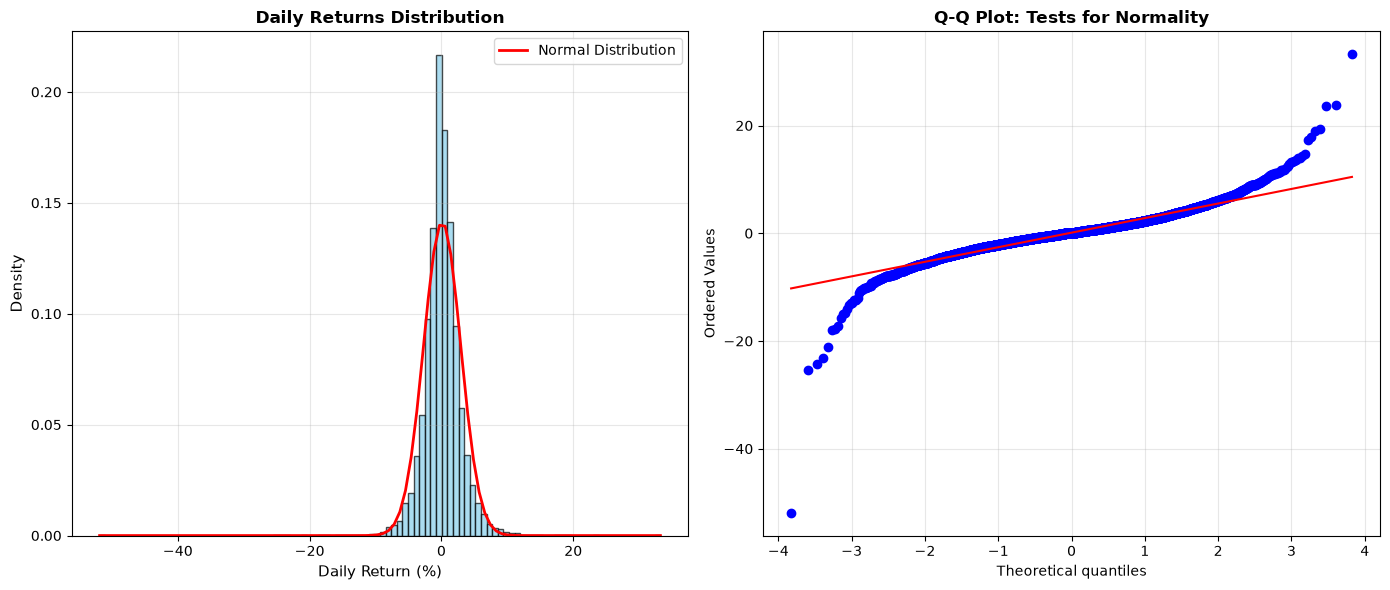

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Your df is already loaded
df['Daily_Return'] = df['Adj Close'].pct_change() * 100
returns = df['Daily_Return'].dropna()

print("="*80)
print("JARQUE-BERA NORMALITY TEST")
print("="*80)

# Jarque-Bera Test
jb_stat, jb_p = stats.jarque_bera(returns)

print(f"\nDaily Returns Statistics:")
print(f"  Mean:     {returns.mean():.4f}%")
print(f"  Std Dev:  {returns.std():.4f}%")
print(f"  Skewness: {stats.skew(returns):.4f}")
print(f"  Kurtosis: {stats.kurtosis(returns):.4f}")

print(f"\nJarque-Bera Test Result:")
print(f"  Test Statistic: {jb_stat:.4f}")
print(f"  P-Value: {jb_p:.10f}")

if jb_p < 0.05:
    print(f"\n✗ RESULT: Returns are NOT normally distributed")
    print(f"  (Reject null hypothesis at 5% significance level)")
else:
    print(f"\n✓ RESULT: Returns appear normally distributed")

print(f"\nInterpretation:")
print(f"  - High skewness ({stats.skew(returns):.2f}) = asymmetrical distribution")
print(f"  - High kurtosis ({stats.kurtosis(returns):.2f}) = fat tails (extreme events)")

# ============================================
# Q-Q PLOT (Most Impressive Visualization)
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Histogram
ax1.hist(returns, bins=100, density=True, alpha=0.7, color='skyblue', edgecolor='black')
mu = returns.mean()
sigma = returns.std()
x = np.linspace(returns.min(), returns.max(), 100)
ax1.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')
ax1.set_title('Daily Returns Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Daily Return (%)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Q-Q Plot (Most Impressive!)
stats.probplot(returns, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot: Tests for Normality', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()